In [1]:
import run

In [2]:
import pandas as pd

In [3]:
from src import data_broker
from src import calendar_iterator
from src import strategy_selector_1
from src import filter_optimizer_1
from src import performance_evaluator_1,performance_evaluator

In [4]:
# params
initial_capital= 100000.0
transaction_cost_pct=.001
forward_month=6
allocation_type='score_weighted'

In [5]:
# 1. Set up all components
tickers=['SPY','QQQ','QQQE','IWM','XSW','XLY','XLV','XLU','XLRE','XLP','XLK','XLI','XLF','XLE','XLC','XLB','XBI'] #,'VXX']
# tickers=["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL"]
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-06-01")
universe_data = broker.fetch_universe_data()
is_data,oos_data=broker.split_train_test(universe_data,forward_month)

[*********************100%***********************]  17 of 17 completed


In [6]:
calendar = calendar_iterator.CalendarIterator(is_data, interval="ME")
rebalance_dates = calendar.generate_rebalance_dates()
portfolio_filter = filter_optimizer_1.VolumeWeightFilter(top_percent=0.40, min_dollar_volume=10_000_000, allocation_type=allocation_type)

In [7]:
strateties={
    'info':strategy_selector_1.InformationDiscreteMomentum(lookback_days=252),
    'info_std2':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=2),
    'info_std3':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=3),
    'adj_mom':strategy_selector_1.RiskAdjustedMomentum(lookback_days=252),
    'raw_mom':strategy_selector_1.MomentumStrategy(lookback_days=252)
}

    

In [8]:
evaluators,nav_dfs,reports={},{},{}

for strategy_key in strateties:
    strategy=strateties[strategy_key]
    evaluator= run.run(universe_data,rebalance_dates, calendar,strategy,portfolio_filter)
    df_nav,report=run.get_df_nav(evaluator)

    evaluators[strategy_key]=strategy
    nav_dfs[strategy_key]=df_nav
    reports[strategy_key]=report

In [9]:
for key in reports:
    report=reports[key]
    print(key)
    run.display_report(report)

info


,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,11.19%,32.13%
Annualized Volatility,13.69%,12.99%
Sharpe Ratio,0.520000,2.170000
Sortino Ratio,0.590000,3.240000
Max Drawdown,-16.52%,-7.96%


info_std2


,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,9.82%,32.13%
Annualized Volatility,13.68%,12.99%
Sharpe Ratio,0.430000,2.170000
Sortino Ratio,0.480000,3.240000
Max Drawdown,-17.07%,-7.96%


info_std3


,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,10.1%,32.13%
Annualized Volatility,13.64%,12.99%
Sharpe Ratio,0.450000,2.170000
Sortino Ratio,0.500000,3.240000
Max Drawdown,-16.52%,-7.96%


adj_mom


,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,10.06%,25.77%
Annualized Volatility,12.62%,13.15%
Sharpe Ratio,0.480000,1.660000
Sortino Ratio,0.560000,2.750000
Max Drawdown,-15.37%,-7.69%


raw_mom


,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,9.91%,27.71%
Annualized Volatility,13.04%,13.68%
Sharpe Ratio,0.450000,1.730000
Sortino Ratio,0.520000,2.940000
Max Drawdown,-16.97%,-7.82%


In [10]:
evaluator= run.run(universe_data,rebalance_dates, calendar,strategy,portfolio_filter)
df_nav,report=run.get_df_nav(evaluator)
run.display_report(report)

,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,9.91%,27.71%
Annualized Volatility,13.04%,13.68%
Sharpe Ratio,0.450000,1.730000
Sortino Ratio,0.520000,2.940000
Max Drawdown,-16.97%,-7.82%


In [11]:
nav_dfs.keys()

dict_keys(['info', 'info_std2', 'info_std3', 'adj_mom', 'raw_mom'])

In [12]:
key1='info'
key2='info_std2'
key3='info_std3'
key4='adj_mom'
key5='raw_mom'

In [13]:
df_nav=nav_dfs[key1]
df_nav2=nav_dfs[key2]
df_nav3=nav_dfs[key3]

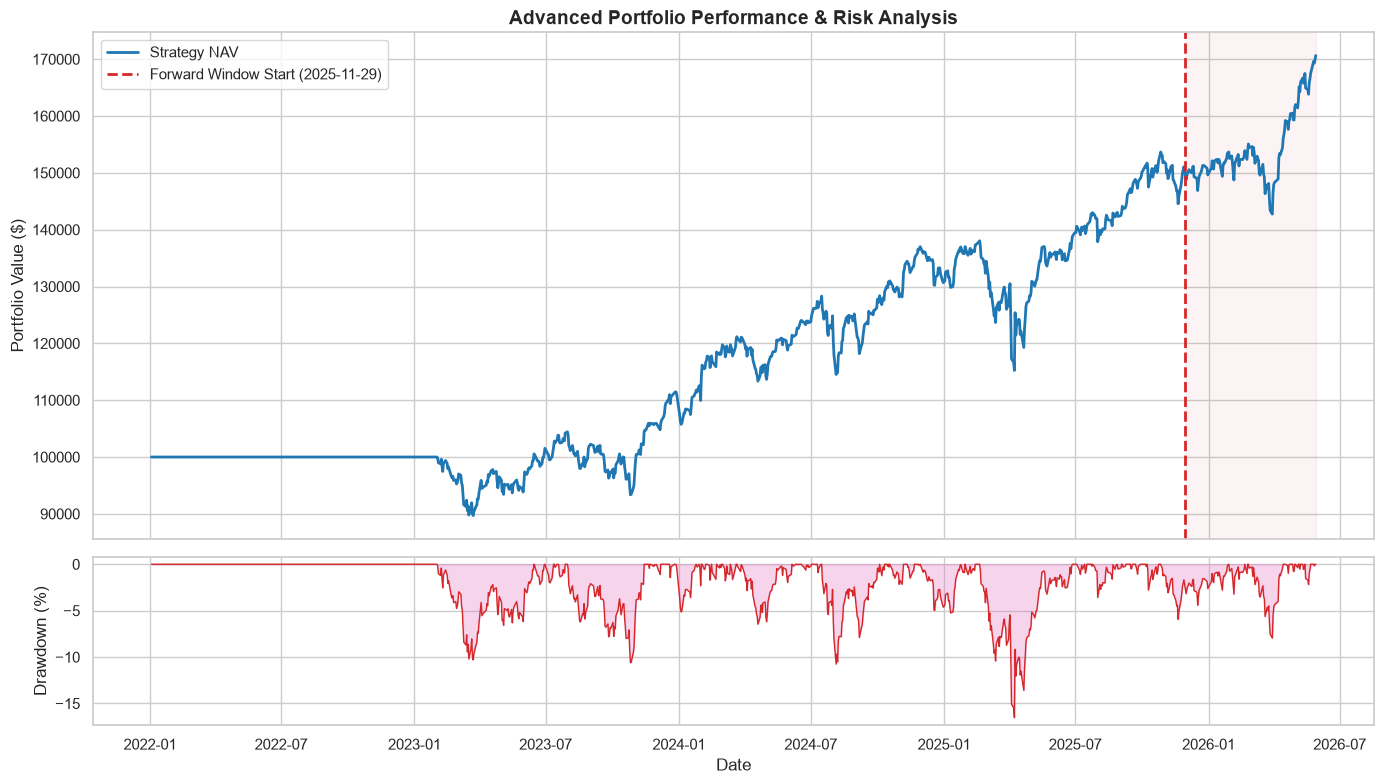

In [14]:
run.plot_nav_charts(df_nav)

In [15]:
#import matplotlib.pyplot as plt
# plt.figure(figsize=(14, 6))
# for key in nav_dfs:
#     df_nav=nav_dfs[key]
#     plt.plot(df_nav, label=key) #, )color='gray', alpha=0.7)

# plt.title('Alpha Comparison: Checking the Impact of Volume Exhaustion')
# plt.ylabel('Portfolio Value ($)')
# plt.legend()
# plt.show()

In [16]:
import plotly.graph_objects as go
import pandas as pd

# Initialize the Plotly figure
fig = go.Figure()

for key, df_nav in nav_dfs.items():
    # Detect if the value is a DataFrame (take first column) or a Series
    y_values = df_nav.iloc[:, 0] if isinstance(df_nav, pd.DataFrame) else df_nav
    
    fig.add_trace(go.Scatter(
        x=df_nav.index,
        y=y_values,
        mode='lines',
        name=key
    ))

# Update layout to match your titles and dimensions
fig.update_layout(
    title='Alpha Comparison: Checking the Impact of Volume Exhaustion',
    xaxis_title='Index / Date',
    yaxis_title='Portfolio Value ($)',
    width=1200,   # Adjust width to match your screen preferences (corresponds to 14)
    height=550,   # Adjust height (corresponds to 6)
    template='plotly_white', # Clean background style
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Display the interactive chart
fig.show()

In [17]:
import plotly.io as pio
pio.renderers.default = "iframe"

In [18]:
fig.show()

In [19]:
df_navs= pd.concat(nav_dfs,axis=1)
df_navs.columns=nav_dfs.keys()
df_navs.tail()

,info,info_std2,info_std3,adj_mom,raw_mom
date,,,,,
2026-05-22,167543.431756,159660.843145,161292.000485,156443.987433,156530.316994
2026-05-26,169610.786737,161630.933144,163282.217691,157914.762524,158109.411116
2026-05-27,169313.454595,161347.589894,162995.979696,158077.438382,158263.697322
2026-05-28,169985.784216,161988.287731,163643.223151,159132.226735,159395.115689
2026-05-29,170649.172443,162620.464847,164281.858835,159562.082933,159967.133511


In [20]:
df_returns=df_navs.pct_change().dropna()

In [21]:
import plotly.express as px

# Generate the summary statistics
df_stats = df_returns.describe().transpose()

# Create the scatter plot using the index as the 'text' argument
fig = px.scatter(
    df_stats, 
    x='std', 
    y='mean', 
    text=df_stats.index,  # This puts the labels on the chart
    title='Strategy Risk vs. Return (Mean vs. Std Dev)'
)

# Tweak label positioning so they don't sit directly on top of the dots
fig.update_traces(textposition='top center')
fig.show()

In [22]:
# approximate sharpe ratio
(df_stats['mean']/df_stats['std']).sort_values(ascending=False)

info         0.060676
adj_mom      0.056888
info_std3    0.056840
info_std2    0.055614
raw_mom      0.055571
dtype: float64

In [23]:
df_metrics=run.compute_performance_metrics(df_navs)

# bench mark

In [24]:
broker = data_broker.DataBroker(tickers=["SPY","QQQ"], start_date="2022-01-01", end_date="2026-06-01")
benchmark_data = broker.fetch_universe_data()['price']

[*********************100%***********************]  2 of 2 completed


In [25]:
df_metrics_benchmark=run.compute_performance_metrics(benchmark_data)

In [26]:
run.calculate_cagr(df_navs).sort_values()

adj_mom      0.112047
raw_mom      0.112688
info_std2    0.116856
info_std3    0.119440
info         0.129157
Name: CAGR, dtype: float64

In [27]:
run.calculate_cagr(benchmark_data).sort_values()

SPY    0.124945
QQQ    0.155309
Name: CAGR, dtype: float64

In [28]:
df_metrics.sort_values('Sharpe Ratio', ascending=False)

,CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
info,12.961996,0.675429,0.786046,-16.522694,0.784497
info_std3,11.986620,0.613475,0.713503,-16.522694,0.725464
info_std2,11.727328,0.594934,0.690224,-17.073075,0.686890
adj_mom,11.244613,0.594348,0.718832,-15.372897,0.731457
raw_mom,11.308952,0.583553,0.698079,-16.965572,0.666582


In [29]:
df_metrics_benchmark

,CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
QQQ,15.587264,0.571465,0.815108,-34.827975,0.44755
SPY,12.539211,0.536093,0.741277,-24.496404,0.51188
